# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023.

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately.
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv("data/cleaned_aviation_data.csv", encoding = "latin1")
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16370 entries, 0 to 16369
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Event.Id                   16370 non-null  object 
 1   Investigation.Type         16370 non-null  object 
 2   Accident.Number            16370 non-null  object 
 3   Event.Date                 16370 non-null  object 
 4   Location                   16367 non-null  object 
 5   Country                    16369 non-null  object 
 6   Latitude                   15360 non-null  object 
 7   Longitude                  15356 non-null  object 
 8   Airport.Code               11154 non-null  object 
 9   Airport.Name               11252 non-null  object 
 10  Injury.Severity            16370 non-null  object 
 11  Aircraft.damage            16370 non-null  object 
 12  Aircraft.Category          16370 non-null  object 
 13  Registration.Number        16253 non-null  obj

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Report.Status', 'Publication.Date', 'Total.Passengers',
       'Serious+Fatal', 'Serious.Fatal.Injury.Rate', 'Year', 'Destroyed',
       'Make_Model'],
      dtype='object')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types.

In [3]:
df["Aircraft.Size"] = np.where(
    df["Total.Passengers"] <= 20,
    "Small",
    "Large"
)
df.value_counts("Aircraft.Size")

Aircraft.Size
Small    15946
Large      424
Name: count, dtype: int64

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [4]:
# Grouping injury rate by plane size and make
make_injury_rate = df.groupby(["Aircraft.Size", "Make"]
).agg(total_accidents = ("Make","count"),
     mean_injury_rate=("Serious.Fatal.Injury.Rate", "mean")
).reset_index()

# 15 SMALL makes with lowest fatal/seriously injured mean, safe planes
small_safe = (make_injury_rate[make_injury_rate["Aircraft.Size"] == "Small"]
    .sort_values("mean_injury_rate").head(15)
    )

# 15 LARGE makes with lowest fatal/seriously injured mean
large_safe = (make_injury_rate[make_injury_rate["Aircraft.Size"] == "Large"]
    .sort_values("mean_injury_rate").head(15))

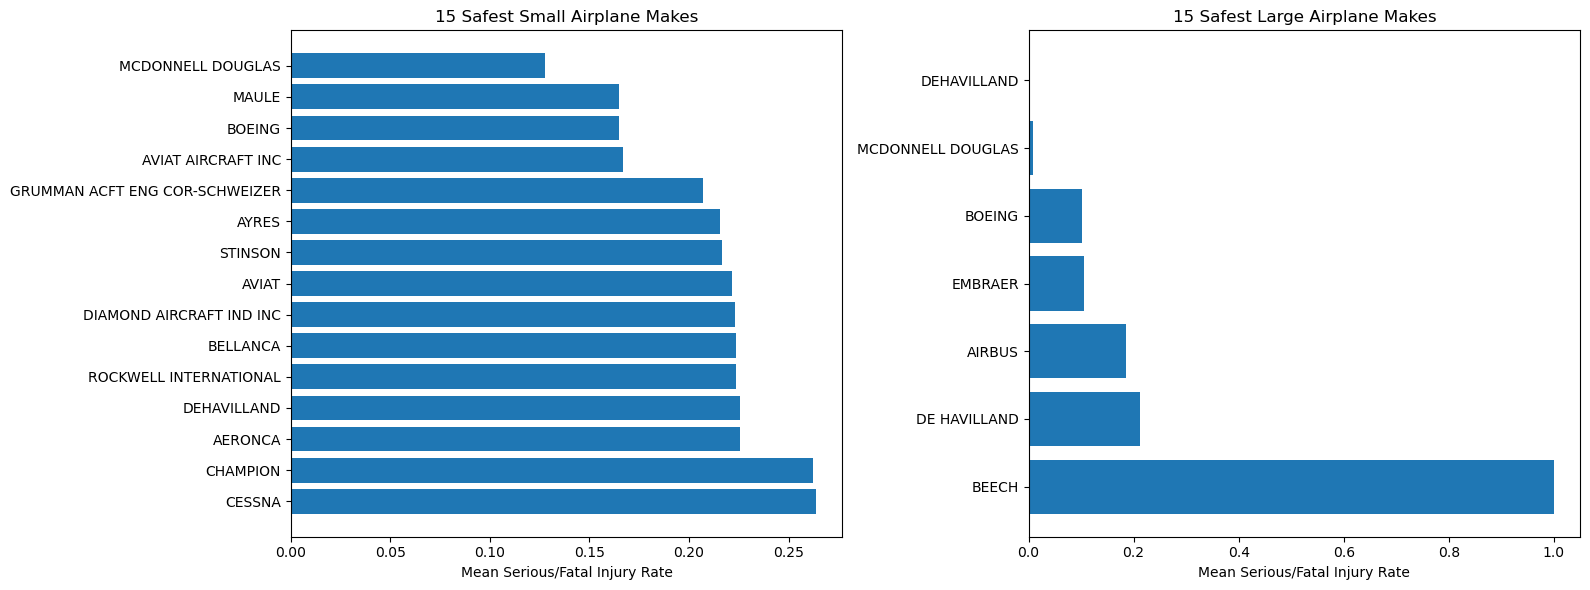

In [5]:
# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Small planes
axes[0].barh(small_safe["Make"], small_safe["mean_injury_rate"])

axes[0].set_title("15 Safest Small Airplane Makes")
axes[0].set_xlabel("Mean Serious/Fatal Injury Rate")
axes[0].invert_yaxis()

# Large planes
axes[1].barh(large_safe["Make"], large_safe["mean_injury_rate"])

axes[1].set_title("15 Safest Large Airplane Makes")
axes[1].set_xlabel("Mean Serious/Fatal Injury Rate")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

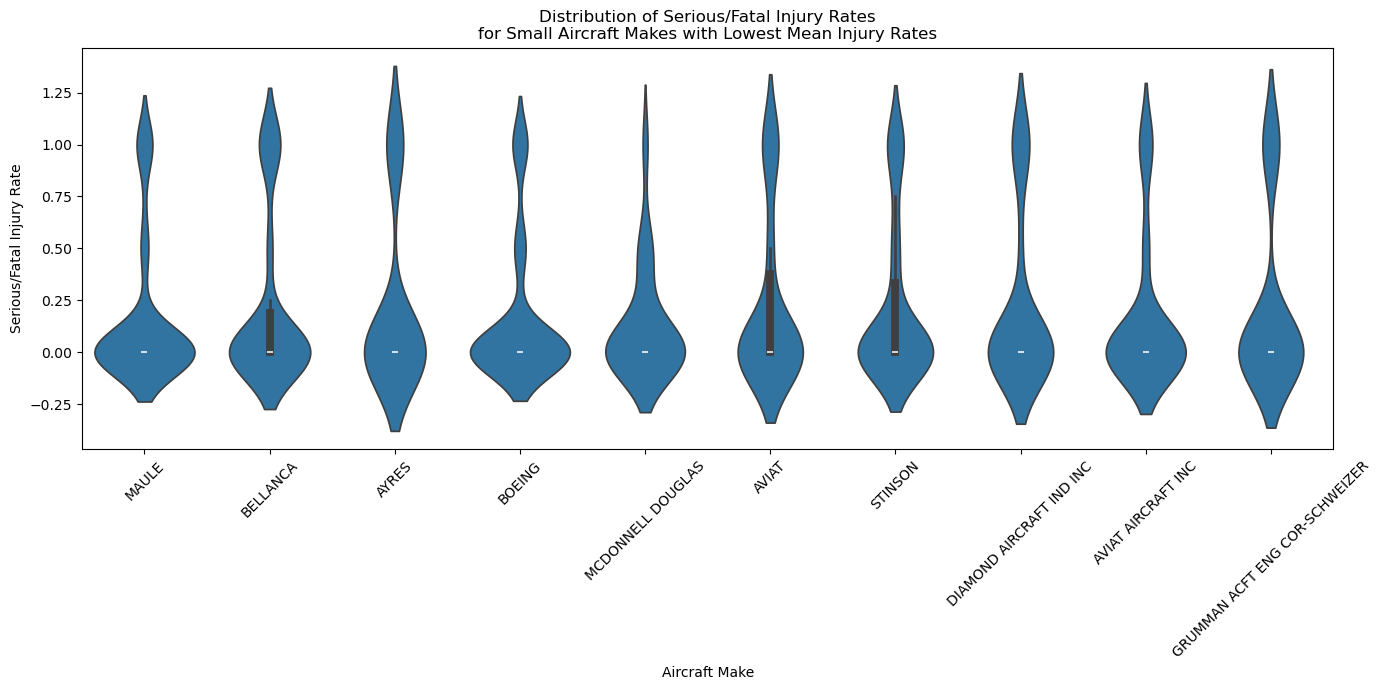

In [6]:
# To get 10 small plane with lowest mean serious/fatal injury rates.
ten_small_safe = (small_safe["Make"].head(10))

# Filter data for those 10 makes
small_violin = df[(df["Aircraft.Size"] == "Small")
&(df["Make"].isin(ten_small_safe))]

# Creating the violin plot
plt.figure(figsize=(14,7))

sns.violinplot(data=small_violin, x="Make", y="Serious.Fatal.Injury.Rate")

plt.title("Distribution of Serious/Fatal Injury Rates\nfor Small Aircraft Makes with Lowest Mean Injury Rates") # keep centre

plt.xlabel("Aircraft Make")
plt.ylabel("Serious/Fatal Injury Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

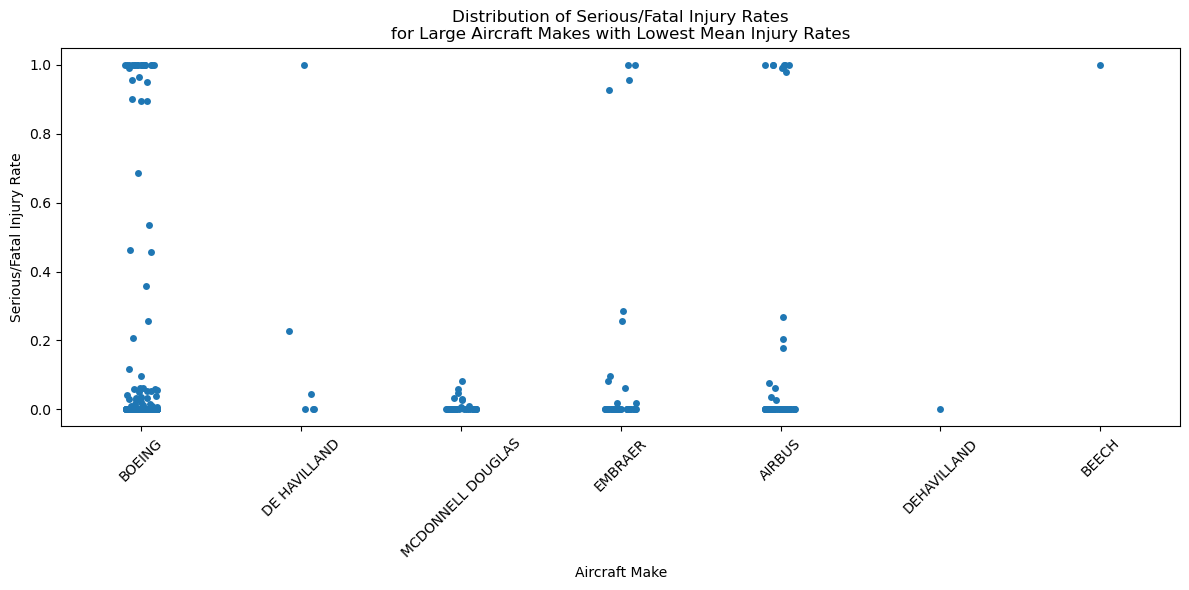

In [7]:
# Filter same as small
# To get 10 large plane with lowest mean serious/fatal injury rates.
ten_large_safe = (large_safe["Make"].head(10))

# Filter data for those 10 makes
large_strip = df[(df["Aircraft.Size"] == "Large")
&(df["Make"].isin(ten_large_safe))]

# Strip plot
plt.figure(figsize=(12,6))

sns.stripplot(data=large_strip, x="Make", y="Serious.Fatal.Injury.Rate")

plt.title("Distribution of Serious/Fatal Injury Rates\nfor Large Aircraft Makes with Lowest Mean Injury Rates")

plt.xlabel("Aircraft Make")
plt.ylabel("Serious/Fatal Injury Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.**

Sort your results and keep the lowest 15.

In [8]:
# Group by size and make
destruction_rate = df.groupby(["Aircraft.Size", "Make"]
).agg(mean_destruction_rate = ("Destroyed","mean")).reset_index()

# 15 lowest destruction rates for small aircraft
small_destruction = (destruction_rate[destruction_rate["Aircraft.Size"] == "Small"]
    .sort_values("mean_destruction_rate").head(15))
small_destruction


,Aircraft.Size,Make,mean_destruction_rate
30,Small,LUSCOMBE,0.014388
29,Small,GRUMMAN ACFT ENG COR-SCHWEIZER,0.017241
39,Small,STINSON,0.023256
40,Small,TAYLORCRAFT,0.032258
8,Small,AERONCA,0.035000
27,Small,ERCOUPE,0.038462
12,Small,AMERICAN CHAMPION AIRCRAFT,0.039216
14,Small,AVIAT AIRCRAFT INC,0.040000
31,Small,MAULE,0.041860
24,Small,DEHAVILLAND,0.043956


In [9]:
# 15 lowest destruction rates for large aircraft
large_destruction = (destruction_rate[destruction_rate["Aircraft.Size"] == "Large"]
    .sort_values("mean_destruction_rate").head(15))
large_destruction

,Aircraft.Size,Make,mean_destruction_rate
4,Large,DEHAVILLAND,0.000000
5,Large,EMBRAER,0.088889
2,Large,BOEING,0.095745
6,Large,MCDONNELL DOUGLAS,0.111111
3,Large,DE HAVILLAND,0.166667
0,Large,AIRBUS,0.169811
1,Large,BEECH,1.000000


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

There is significantly more data for avilable for small planes tha larger ones, which creates a much bigger difference when comparing the sizes.
On rate of serious/fatal injures, small planes show to be less likely to lead to severe injuries. The lowest 15 small plane had a range of approximately 0.15 to 0.255 while large shows 0-1, though only one make had a mean of 1, while the other fall btween 0-0.22. Statistically, it shows that larger planes have lower rates, but would be better with a larger sample size.

The violin plots showed that most makes have lower average injury rates, with the distribution concentrated on the lower values. With the strip plot shows a partern of extremes, that is low and high with less values shows around the centre. This may indicated that although large planes might be safe due to low injury rates, the also exhibit high injury rates, close to 1.

The destruction rate analysis further supported these findings. Manufacturers with lower proportions of completely destroyed aircraft may indicate stronger structural survivability and better protection of passengers during accidents. Makes that consistently ranked well across both injury and destruction metrics would therefore be stronger candidates for recommendation to the client.

Boing and Maule are consitently seen with low rates of inury and possible destruction in aircraft accidents.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

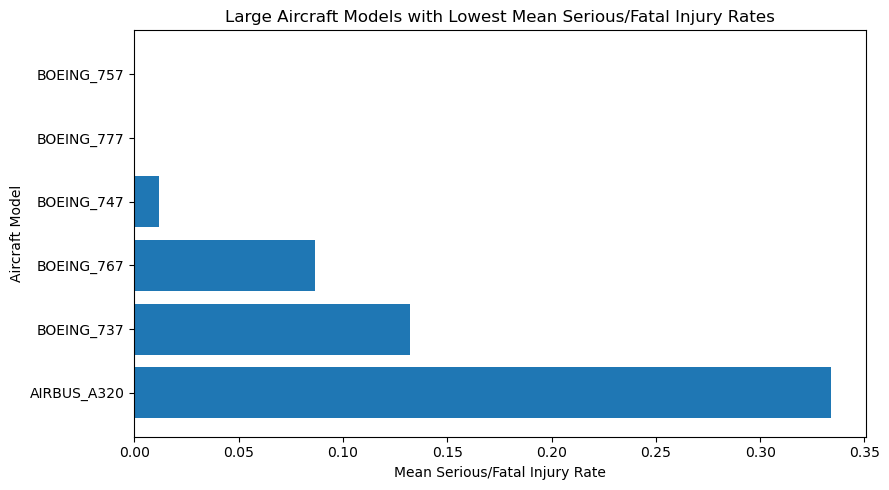

,Make_Model,mean_injury_rate,Total_Accidents
3,BOEING_757,0.000000,9
5,BOEING_777,0.000000,16
2,BOEING_747,0.011927,8
4,BOEING_767,0.086505,15
1,BOEING_737,0.132325,98
0,AIRBUS_A320,0.333975,9


In [15]:
# Keep only plane types with at least 10 observations
plane_counts = df["Make_Model"].value_counts()
valid_planes = plane_counts[plane_counts >= 10].index
plane_df = df[df["Make_Model"].isin(valid_planes)]

# filter large planes
large_plane = plane_df[plane_df["Aircraft.Size"] == "Large"]

# Calculate mean injury rate for large
large_plane_risk = large_plane.groupby("Make_Model").agg(mean_injury_rate=("Serious.Fatal.Injury.Rate", "mean"),
        Total_Accidents=("Make_Model", "count")).reset_index()
# Sort
large_plane_risk = (large_plane_risk.sort_values("mean_injury_rate").head(15))

# Bar Chart
plt.figure(figsize=(9,5))

plt.barh(large_plane_risk["Make_Model"],large_plane_risk["mean_injury_rate"])
plt.title("Large Aircraft Models with Lowest Mean Serious/Fatal Injury Rates")

plt.xlabel("Mean Serious/Fatal Injury Rate")
plt.ylabel("Aircraft Model")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


large_plane_risk

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

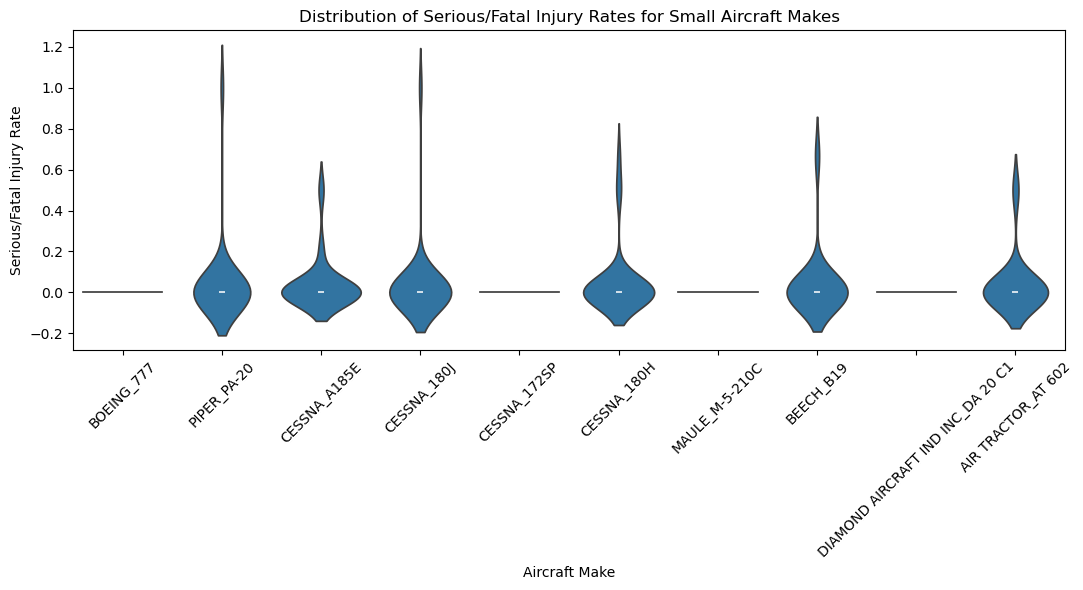

,Make_Model,mean_injury_rate,Total_Accidents
211,DIAMOND AIRCRAFT IND INC_DA 20 C1,0.000000,11
225,MAULE_M-5-210C,0.000000,11
110,CESSNA_172SP,0.000000,12
72,BOEING_777,0.000000,5
118,CESSNA_180J,0.035714,28
173,CESSNA_A185E,0.038889,18
267,PIPER_PA-20,0.040000,25
47,BEECH_B19,0.041667,16
16,AIR TRACTOR_AT 602,0.041667,12
117,CESSNA_180H,0.049020,34


In [19]:
# Keep only plane types with at least 10 observations
plane_counts = df["Make_Model"].value_counts()
valid_planes = plane_counts[plane_counts >= 10].index
plane_df = df[df["Make_Model"].isin(valid_planes)]

# filter small planes
small_plane = plane_df[plane_df["Aircraft.Size"] == "Small"]

# Calculate mean injury rate for large
small_plane_risk = small_plane.groupby("Make_Model").agg(mean_injury_rate=("Serious.Fatal.Injury.Rate", "mean"),
        Total_Accidents=("Make_Model", "count")).reset_index()
# Sort
small_plane_risk = (small_plane_risk.sort_values("mean_injury_rate").head(10))

# Distribution plot
small_distribution = small_plane[small_plane["Make_Model"].isin(small_plane_risk["Make_Model"])]

plt.figure(figsize=(11,6))

sns.violinplot(data=small_distribution, x="Make_Model", y="Serious.Fatal.Injury.Rate")

plt.title("Distribution of Serious/Fatal Injury Rates for Small Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Serious/Fatal Injury Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

small_plane_risk

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

For the Large planes, the Boeing had the least mean serious/fatal injuries, with Boeing 777 and 757 having a mean of 0, indicating to be the safest boeing models.

The small planes, the data shows 4 Makes(boeing,cessna, diamond craft and maule) presenting models with 0 mean rate of injuries. Compared to large, the small planes have less rate of serious/fatal injuries.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [12]:
# Let's see how weather condictions and no. of engines have any relation to the accidents
# Group by weather condition
weather_summary = df.groupby("Weather.Condition").agg(
    mean_injury_rate=("Serious.Fatal.Injury.Rate", "mean"),
    mean_destruction_rate=("Destroyed", "mean"),
    total_accidents=("Weather.Condition", "count")
).reset_index()

weather_summary


,Weather.Condition,mean_injury_rate,mean_destruction_rate,total_accidents
0,IMC,0.663147,0.373223,844
1,UNK,0.557908,0.394118,170
2,VMC,0.236539,0.072427,13945


## Weather Condition
Weather conditions appear to influence accident severity. The accidents occurring during IMC generally showed higher serious/fatal injury rates compared to VMC. This may be attributed to poor visibility and more difficult flying conditions. The destruction rates also tended to be higher under adverse weather conditions, that is UNK & IMC, suggesting that weather is an important contributing factor in aviation safety outcomes.

In [13]:
# Exclude missing engine counts and 0
engine_df = df[(df["Number.of.Engines"].notna()) & (df["Number.of.Engines"] > 0)]

# Group by number of engines
engine_summary = engine_df.groupby("Number.of.Engines").agg(
    mean_injury_rate=("Serious.Fatal.Injury.Rate", "mean"),
    mean_destruction_rate=("Destroyed", "mean"),
    total_accidents=("Number.of.Engines", "count")
).reset_index()

engine_summary

,Number.of.Engines,mean_injury_rate,mean_destruction_rate,total_accidents
0,1.0,0.255848,0.077703,13114
1,2.0,0.326520,0.175661,1890
2,3.0,0.104824,0.062500,16
3,4.0,0.190379,0.166667,36


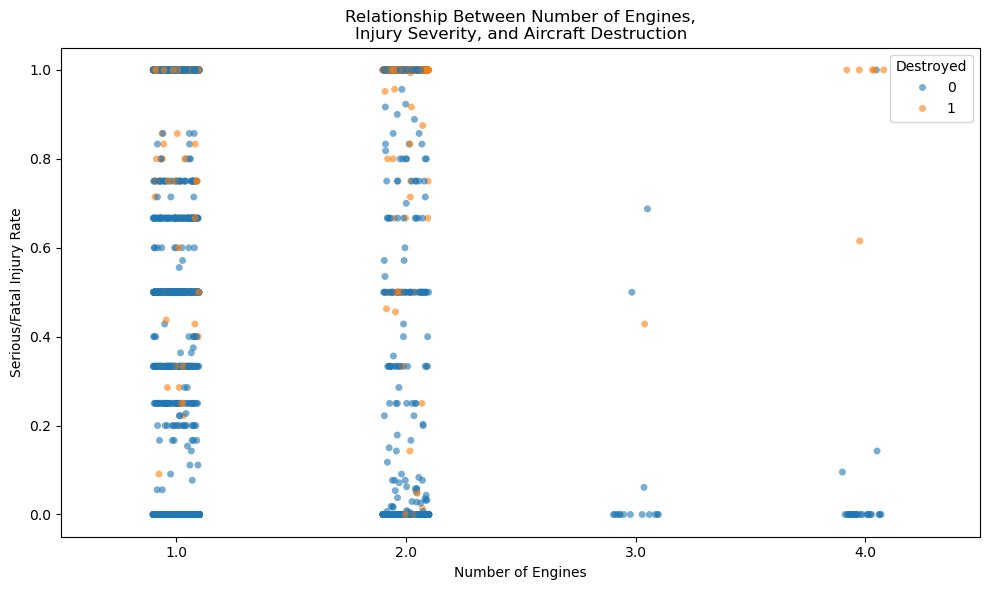

In [14]:
# Phase of flight calculations
plt.figure(figsize=(10,6))

sns.stripplot(data=engine_df, x="Number.of.Engines", y="Serious.Fatal.Injury.Rate",
    hue="Destroyed", jitter=True, alpha=0.6)

plt.title("Relationship Between Number of Engines,\nInjury Severity, and Aircraft Destruction")
plt.xlabel("Number of Engines")
plt.ylabel("Serious/Fatal Injury Rate")
plt.tight_layout()
plt.show()